In [1]:
# Cell 1: imports & reproducibility
import os, random, time
import numpy as np, pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Reproducibility
def set_seed(seed=42):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


In [2]:
# Cell 2: load data but keep Attack Type categories
def load_cicids2017(path, min_samples_per_attack=200):
    df = pd.read_csv(path).dropna(axis=1, how='all').dropna()
    if 'Attack Type' not in df.columns and 'Label' in df.columns:
        df = df.rename(columns={'Label': 'Attack Type'})
    # Keep the raw attack labels
    df['Attack Type'] = df['Attack Type'].astype(str)
    # encode non-numeric columns
    obj_cols = [c for c in df.columns if df[c].dtype == 'object' and c!='Attack Type']
    for c in obj_cols:
        df[c] = LabelEncoder().fit_transform(df[c].astype(str))
    # Filter very small attack classes (optional)
    counts = df['Attack Type'].value_counts()
    good_labels = counts[counts >= min_samples_per_attack].index.tolist()
    # Always keep 'Normal Traffic' if present
    if 'Normal Traffic' in counts.index and 'Normal Traffic' not in good_labels:
        good_labels.append('Normal Traffic')
    df = df[df['Attack Type'].isin(good_labels)].copy()
    # Build features and separate Attack Type label
    y_attack = df['Attack Type'].values
    X = df.drop(columns=['Attack Type']).values
    X = StandardScaler().fit_transform(X)
    return X, y_attack, df.columns.drop('Attack Type').tolist()

# Update path -> your local path
path = r"C:\Users\chari\Downloads\cicids2017_cleaned.csv"
X_all, y_attack, feature_names = load_cicids2017(path, min_samples_per_attack=200)
print("Loaded shape:", X_all.shape, "unique attack labels:", np.unique(y_attack).shape)


Loaded shape: (2520751, 52) unique attack labels: (7,)


In [3]:
# Cell 3: create tasks (each attack label becomes a binary task: attack vs Normal Traffic)
def build_tasks(X, y_attack, feature_names, normal_label='Normal Traffic', min_support=50):
    labels = np.unique(y_attack)
    tasks = []
    for lab in labels:
        if lab == normal_label:
            continue
        idx_pos = np.where(y_attack == lab)[0]
        idx_neg = np.where(y_attack == normal_label)[0]
        # ensure enough samples
        if len(idx_pos) <  min_support or len(idx_neg) < min_support:
            continue
        # store indices
        tasks.append({
            'attack_label': lab,
            'pos_idx': idx_pos,
            'neg_idx': idx_neg
        })
    return tasks

tasks = build_tasks(X_all, y_attack, feature_names, normal_label='Normal Traffic', min_support=100)
print("Number of tasks (attack families):", len(tasks))
print("Example tasks:", [t['attack_label'] for t in tasks][:10])


Number of tasks (attack families): 6
Example tasks: ['Bots', 'Brute Force', 'DDoS', 'DoS', 'Port Scanning', 'Web Attacks']


In [4]:
# Cell 4: (optional) run a fast QAOA-like selector to reduce features
# We'll use a lightweight version of your earlier QAOA class but quicker:
class FastQAOA:
    def __init__(self, X, y, rng_seed=42):
        self.X = X
        self.y = y
        self.rng = np.random.RandomState(rng_seed)
        self.n = X.shape[1]
    def optimize(self, n_features=60, iters=30):
        # score features by univariate mutual info surrogate: use variance * correlation with label
        scores = []
        ynum = (np.array(self.y) != 'Normal Traffic').astype(int)
        # compute simple relevance
        for j in range(self.n):
            col = self.X[:, j]
            # small heuristic: absolute pearson with label * variance
            try:
                corr = abs(np.corrcoef(col, ynum)[0,1])
            except Exception:
                corr = 0.0
            scores.append(corr * np.var(col))
        idx = np.argsort(scores)[-n_features:]
        return np.sort(idx)

# Run fast selector
q = FastQAOA(X_all, y_attack)
selected_idx = q.optimize(n_features=min(120, X_all.shape[1]))
print("Selected feature count:", len(selected_idx))
# reduce data
X_sel = X_all[:, selected_idx]
print("Reduced X shape:", X_sel.shape)



Selected feature count: 52
Reduced X shape: (2520751, 52)


In [5]:
# Cell 5: Model (BiLSTM + MultiHead Attention)
import math
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, attn_dropout=0.0):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.qkv = nn.Linear(embed_dim, embed_dim * 3)
        self.out = nn.Linear(embed_dim, embed_dim)
        self.drop = nn.Dropout(attn_dropout)
    def forward(self, x):
        B, T, C = x.size()  # expect T=1 in our usage but ok
        qkv = self.qkv(x).reshape(B, T, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        attn = torch.softmax(attn, dim=-1)
        out = (attn @ v).transpose(1, 2).reshape(B, T, C)
        out = self.drop(out)
        return self.out(out)

class IDSModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_heads=4, dropout=0.1, attn_dropout=0.0, num_classes=2):
        super().__init__()
        self.bilstm = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim, num_layers=1, batch_first=True, bidirectional=True)
        self.attn = MultiHeadSelfAttention(embed_dim=hidden_dim*2, num_heads=num_heads, attn_dropout=attn_dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)
    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(1)  # (batch, 1, input_dim)
        lstm_out, _ = self.bilstm(x)      # (batch, 1, 2*hidden)
        attn_out = self.attn(lstm_out)    # (batch, 1, 2*hidden)
        out = attn_out[:, -1, :]          # last step
        out = self.dropout(out)
        return self.fc(out)


In [6]:
# Cell 6: sampling few-shot support & query for a given task
def sample_task_batch(task, X, y_attack, support_k=20, query_k=40, rng=None):
    if rng is None: rng = np.random.RandomState()
    pos = task['pos_idx']
    neg = task['neg_idx']
    # sample support and query from each class
    pos_perm = rng.choice(pos, size=min(len(pos), support_k+query_k), replace=False)
    neg_perm = rng.choice(neg, size=min(len(neg), support_k+query_k), replace=False)
    pos_support = pos_perm[:support_k]
    pos_query = pos_perm[support_k:support_k+query_k]
    neg_support = neg_perm[:support_k]
    neg_query = neg_perm[support_k:support_k+query_k]
    support_idx = np.concatenate([pos_support, neg_support])
    query_idx = np.concatenate([pos_query, neg_query])
    # create X, y (binary: attack=1, normal=0)
    y_sup = (y_attack[support_idx] != 'Normal Traffic').astype(int)
    y_q = (y_attack[query_idx] != 'Normal Traffic').astype(int)
    return support_idx, query_idx, X[support_idx], y_sup, X[query_idx], y_q


In [7]:
# Cell 7: Reptile meta-train
def reptile_meta_train(X, y_attack, tasks, model_fn, meta_iters=200, tasks_per_iter=4,
                       inner_steps=5, inner_lr=1e-3, meta_lr=1e-2, support_k=20, query_k=40,
                       batch_size=64, print_every=10):
    rng = np.random.RandomState(42)
    # meta model
    meta_model = model_fn().to(device)
    meta_params = {k: v.data.clone() for k,v in meta_model.state_dict().items()}
    loss_fn = nn.CrossEntropyLoss(weight=torch.tensor([0.5, 0.5], device=device))
    optim = torch.optim.SGD(meta_model.parameters(), lr=1e-3)  # used only to zero grads if needed

    for meta_it in range(1, meta_iters+1):
        # sample tasks_per_iter tasks randomly
        sampled_tasks = rng.choice(tasks, size=min(tasks_per_iter, len(tasks)), replace=False)
        task_weights = []
        for task in sampled_tasks:
            # create a fresh model copy
            worker = model_fn().to(device)
            worker.load_state_dict(meta_model.state_dict())  # initialize from meta
            worker_opt = torch.optim.SGD(worker.parameters(), lr=inner_lr)
            # sample support set for task
            s_idx, q_idx, Xs, ys, Xq, yq = sample_task_batch(task, X, y_attack, support_k=support_k, query_k=query_k, rng=rng)
            # inner loop: train worker on support
            worker.train()
            s_dataset = TensorDataset(torch.tensor(Xs, dtype=torch.float32), torch.tensor(ys, dtype=torch.long))
            s_loader = DataLoader(s_dataset, batch_size=min(batch_size, len(Xs)), shuffle=True)
            for _ in range(inner_steps):
                for xb, yb in s_loader:
                    xb, yb = xb.to(device), yb.to(device)
                    worker_opt.zero_grad()
                    loss = loss_fn(worker(xb), yb)
                    loss.backward()
                    worker_opt.step()
            # after inner updates, compute the difference between worker & meta weights
            diff = {}
            for name, param in meta_model.state_dict().items():
                worker_param = worker.state_dict()[name]
                diff[name] = (worker_param.data - param.data)
            task_weights.append(diff)

        # aggregate diffs (average)
        avg_diff = {}
        for name in meta_model.state_dict().keys():
            avg = sum(d[name] for d in task_weights) / float(len(task_weights))
            avg_diff[name] = avg

        # meta update: theta <- theta + meta_lr * avg_diff
        meta_state = meta_model.state_dict()
        for name in meta_state.keys():
            meta_state[name] = meta_state[name] + meta_lr * avg_diff[name]
        meta_model.load_state_dict(meta_state)

        if meta_it % print_every == 0 or meta_it == 1:
            print(f"[Meta {meta_it}/{meta_iters}] applied meta update (tasks={len(sampled_tasks)})")

    return meta_model

# define model_fn with selected input dim
input_dim = X_sel.shape[1]
def model_fn_factory(hidden_dim=64, num_heads=4, dropout=0.1):
    return IDSModel(input_dim=input_dim, hidden_dim=hidden_dim, num_heads=num_heads, dropout=dropout)

# Run meta-training (adjust hyperparams if needed)
set_seed(42)
meta_model = reptile_meta_train(
    X=X_sel,
    y_attack=y_attack,
    tasks=tasks,
    model_fn=lambda: model_fn_factory(hidden_dim=64, num_heads=4, dropout=0.1),
    meta_iters=120,           # increase for better meta-convergence
    tasks_per_iter=4,
    inner_steps=5,
    inner_lr=1e-2,
    meta_lr=0.1,
    support_k=30,
    query_k=60,
    batch_size=64,
    print_every=20
)
print("Meta-training finished.")


[Meta 1/120] applied meta update (tasks=4)
[Meta 20/120] applied meta update (tasks=4)
[Meta 40/120] applied meta update (tasks=4)
[Meta 60/120] applied meta update (tasks=4)
[Meta 80/120] applied meta update (tasks=4)
[Meta 100/120] applied meta update (tasks=4)
[Meta 120/120] applied meta update (tasks=4)
Meta-training finished.


In [8]:
# Cell 8: Fine-tune meta-model on entire training set (binary normal vs attack) then evaluate on held-out test split
# Build binary labels for final supervised training
binary_labels = (y_attack != 'Normal Traffic').astype(int)
# train/test split (stratified by binary_labels)
train_idx, test_idx = train_test_split(np.arange(len(binary_labels)), test_size=0.2, stratify=binary_labels, random_state=42)
X_train_final, X_test_final = X_sel[train_idx], X_sel[test_idx]
y_train_final, y_test_final = binary_labels[train_idx], binary_labels[test_idx]

# fine-tune
ft_model = model_fn_factory(hidden_dim=64, num_heads=4, dropout=0.1).to(device)
ft_model.load_state_dict(meta_model.state_dict())  # start from meta-params

# data loaders
train_ds = TensorDataset(torch.tensor(X_train_final, dtype=torch.float32), torch.tensor(y_train_final, dtype=torch.long))
test_ds = TensorDataset(torch.tensor(X_test_final, dtype=torch.float32), torch.tensor(y_test_final, dtype=torch.long))
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=512, shuffle=False)

# optimizer and loss (class-weighted)
class_counts = np.bincount(y_train_final)
# compute class weight (inverse frequency)
weights = torch.tensor([1.0/(class_counts[0]+1e-8), 1.0/(class_counts[1]+1e-8)], dtype=torch.float32)
weights = weights / weights.sum()  # normalize
weights = weights.to(device)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.AdamW(ft_model.parameters(), lr=3e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
# train for a few epochs
best_f1 = 0.0
for epoch in range(1, 11):
    ft_model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(ft_model(xb), yb)
        loss.backward()
        optimizer.step()
    # eval
    ft_model.eval()
    preds, gts = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            out = ft_model(xb)
            p = torch.argmax(out, dim=1).cpu().numpy()
            preds.append(p); gts.append(yb.numpy())
    preds = np.concatenate(preds); gts = np.concatenate(gts)
    acc = accuracy_score(gts, preds)
    prec = precision_score(gts, preds, zero_division=0)
    rec = recall_score(gts, preds, zero_division=0)
    f1 = f1_score(gts, preds, zero_division=0)
    scheduler.step(f1)
    if f1 > best_f1:
        best_f1 = f1
        torch.save(ft_model.state_dict(), "best_ft_model.pth")
    print(f"FT Epoch {epoch}: acc={acc:.4f} prec={prec:.4f} rec={rec:.4f} f1={f1:.4f}")

# load best
ft_model.load_state_dict(torch.load("best_ft_model.pth"))
# final evaluation and confusion matrix
ft_model.eval()
all_preds = []
with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        preds = ft_model(xb)
        preds = torch.argmax(preds, dim=1).cpu().numpy()
        all_preds.extend(preds)
all_preds = np.array(all_preds)
acc = accuracy_score(y_test_final, all_preds)
prec = precision_score(y_test_final, all_preds, zero_division=0)
rec = recall_score(y_test_final, all_preds, zero_division=0)
f1 = f1_score(y_test_final, all_preds, zero_division=0)
cm = confusion_matrix(y_test_final, all_preds)

print("\n===== Final Test Results =====")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")
print("\nConfusion Matrix:\n", cm)
print("\nClassification report:\n", classification_report(y_test_final, all_preds, digits=4))


FT Epoch 1: acc=0.9749 prec=0.9036 rec=0.9529 f1=0.9276
FT Epoch 2: acc=0.9636 prec=0.8249 rec=0.9955 f1=0.9022
FT Epoch 3: acc=0.9733 prec=0.8668 rec=0.9949 f1=0.9264
FT Epoch 4: acc=0.9759 prec=0.8823 rec=0.9893 f1=0.9327
FT Epoch 5: acc=0.9717 prec=0.8590 rec=0.9961 f1=0.9225
FT Epoch 6: acc=0.9678 prec=0.8445 rec=0.9916 f1=0.9122
FT Epoch 7: acc=0.9788 prec=0.8965 rec=0.9889 f1=0.9404
FT Epoch 8: acc=0.9739 prec=0.8687 rec=0.9962 f1=0.9281
FT Epoch 9: acc=0.9738 prec=0.8679 rec=0.9967 f1=0.9278
FT Epoch 10: acc=0.9775 prec=0.8853 rec=0.9960 f1=0.9374

===== Final Test Results =====
Accuracy  : 0.9788
Precision : 0.8965
Recall    : 0.9889
F1 Score  : 0.9404

Confusion Matrix:
 [[409289   9723]
 [   945  84194]]

Classification report:
               precision    recall  f1-score   support

           0     0.9977    0.9768    0.9871    419012
           1     0.8965    0.9889    0.9404     85139

    accuracy                         0.9788    504151
   macro avg     0.9471    0.9828

In [ ]:
# Cell 9: pick an unseen attack family (if available) for few-shot adaptation
# If you want to test how quickly it adapts: pick a task (attack family) and do K-shot fine-tune
if len(tasks) > 0:
    t = tasks[0]  # pick first task or change index
    support_idx, query_idx, Xs, ys, Xq, yq = sample_task_batch(t, X_sel, y_attack, support_k=10, query_k=100, rng=np.random.RandomState(999))
    # start from meta params
    adapt_model = model_fn_factory(hidden_dim=64, num_heads=4, dropout=0.1).to(device)
    adapt_model.load_state_dict(meta_model.state_dict())
    opt = torch.optim.SGD(adapt_model.parameters(), lr=1e-2)
    adapt_model.train()
    s_ds = TensorDataset(torch.tensor(Xs, dtype=torch.float32), torch.tensor(ys, dtype=torch.long))
    s_loader = DataLoader(s_ds, batch_size=8, shuffle=True)
    for step in range(10):  # few-shot steps
        for xb, yb in s_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = nn.CrossEntropyLoss()(adapt_model(xb), yb)
            loss.backward()
            opt.step()
    # evaluate on query
    adapt_model.eval()
    with torch.no_grad():
        out = adapt_model(torch.tensor(Xq, dtype=torch.float32).to(device))
        preds = torch.argmax(out, dim=1).cpu().numpy()
    print("Few-shot adaptation results on task:", t['attack_label'])
    print("Acc:", accuracy_score(yq, preds), "F1:", f1_score(yq, preds))


In [9]:
# ================================
# Cell 1: Imports & Reproducibility
# ================================
import os, random, time, math
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Reproducibility
def set_seed(seed=42):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


=== Dataset Summary ===
Shape: (2520751, 52)
Unique Attack Categories: 7
Counts per category:
 Attack Type
Normal Traffic    2095057
DoS                193745
DDoS               128014
Port Scanning       90694
Brute Force          9150
Web Attacks          2143
Bots                 1948
Name: count, dtype: int64


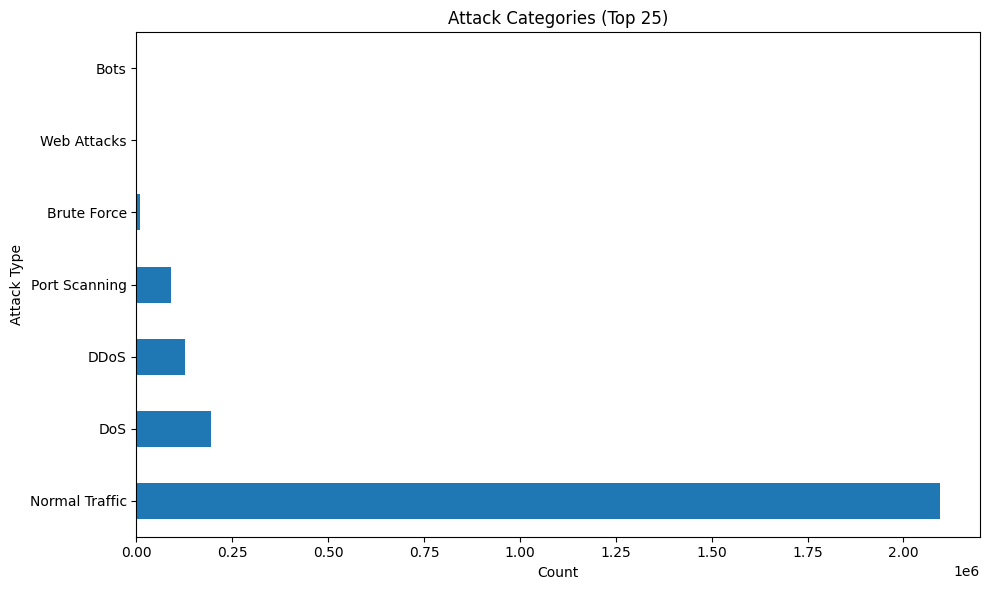

In [10]:
# ======================================
# Cell 2: Dataset Loading + Preprocessing
# ======================================
def load_cicids2017(path, min_samples_per_attack=200):
    df = pd.read_csv(path).dropna(axis=1, how='all').dropna()
    if 'Attack Type' not in df.columns and 'Label' in df.columns:
        df = df.rename(columns={'Label': 'Attack Type'})
    df['Attack Type'] = df['Attack Type'].astype(str)

    # Encode categorical (non Attack Type) cols
    obj_cols = [c for c in df.columns if df[c].dtype == 'object' and c!='Attack Type']
    for c in obj_cols:
        df[c] = LabelEncoder().fit_transform(df[c].astype(str))

    # Filter small attack categories
    counts = df['Attack Type'].value_counts()
    good_labels = counts[counts >= min_samples_per_attack].index.tolist()
    if 'Normal Traffic' in counts.index and 'Normal Traffic' not in good_labels:
        good_labels.append('Normal Traffic')
    df = df[df['Attack Type'].isin(good_labels)].copy()

    y_attack = df['Attack Type'].values
    X = df.drop(columns=['Attack Type']).values
    X = StandardScaler().fit_transform(X)
    return X, y_attack, df.columns.drop('Attack Type').tolist(), counts

# Path
path = r"C:\Users\chari\Downloads\cicids2017_cleaned.csv"
X_all, y_attack, feature_names, counts = load_cicids2017(path, min_samples_per_attack=200)

print("=== Dataset Summary ===")
print("Shape:", X_all.shape)
print("Unique Attack Categories:", np.unique(y_attack).shape[0])
print("Counts per category:\n", counts)

# Plot attack category distribution (top 25)
plt.figure(figsize=(10,6))
counts[:25].plot(kind="barh")
plt.title("Attack Categories (Top 25)")
plt.xlabel("Count")
plt.tight_layout()
plt.show()


In [11]:
# ===================================
# Cell 3: Feature Selection (FastQAOA)
# ===================================
class FastQAOA:
    def __init__(self, X, y, rng_seed=42):
        self.X = X
        self.y = y
        self.rng = np.random.RandomState(rng_seed)
        self.n = X.shape[1]
    def optimize(self, n_features=60):
        scores = []
        ynum = (np.array(self.y) != 'Normal Traffic').astype(int)
        for j in range(self.n):
            col = self.X[:, j]
            try: corr = abs(np.corrcoef(col, ynum)[0,1])
            except: corr = 0.0
            scores.append(corr * np.var(col))
        idx = np.argsort(scores)[-n_features:]
        return np.sort(idx)

# Run fast QAOA feature selector
q = FastQAOA(X_all, y_attack)
selected_idx = q.optimize(n_features=min(120, X_all.shape[1]))
X_sel = X_all[:, selected_idx]

print("=== Feature Selection ===")
print("Selected feature count:", len(selected_idx))
selected_feature_names = [feature_names[i] for i in selected_idx]
print("Selected features list (first 50 shown):")
print(selected_feature_names[:50])


=== Feature Selection ===
Selected feature count: 52
Selected features list (first 50 shown):
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Length of Fwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'Average Packet Size', 'Subflow Fwd Bytes', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_pkt_fwd', '

Params: {'lr': 0.0003, 'epochs': 3, 'batch': 128} F1: 0.9404859019731717
Params: {'lr': 0.0003, 'epochs': 3, 'batch': 256} F1: 0.9425632581116496
Params: {'lr': 0.0003, 'epochs': 5, 'batch': 128} F1: 0.9585550564727354
Params: {'lr': 0.0003, 'epochs': 5, 'batch': 256} F1: 0.9523399994109504
Params: {'lr': 0.0001, 'epochs': 3, 'batch': 128} F1: 0.9420274916173002
Params: {'lr': 0.0001, 'epochs': 3, 'batch': 256} F1: 0.9246263956484397
Params: {'lr': 0.0001, 'epochs': 5, 'batch': 128} F1: 0.9442708581786958
Params: {'lr': 0.0001, 'epochs': 5, 'batch': 256} F1: 0.9392734145804102

=== Hyperparameter Tuning Results ===
       lr  epochs  batch        f1
2  0.0003       5    128  0.958555
3  0.0003       5    256  0.952340
6  0.0001       5    128  0.944271
1  0.0003       3    256  0.942563
4  0.0001       3    128  0.942027
0  0.0003       3    128  0.940486
7  0.0001       5    256  0.939273
5  0.0001       3    256  0.924626


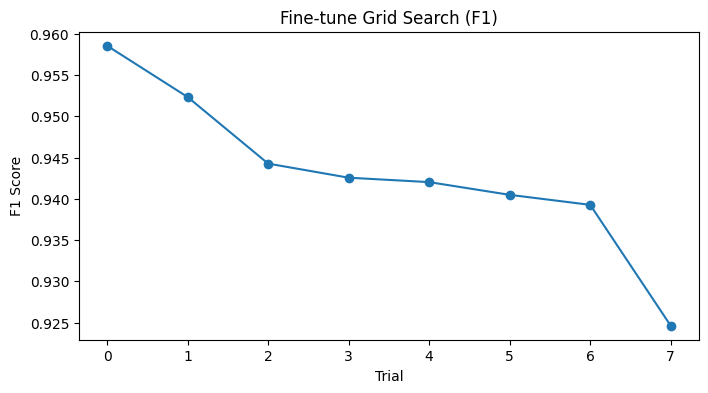

In [12]:
# ===================================
# Cell 4: Hyperparameter Tuning Stage
# ===================================
from sklearn.model_selection import StratifiedShuffleSplit

# Binary labels (Normal vs Attack)
binary_labels_all = (y_attack != 'Normal Traffic').astype(int)

# Quick stratified split (80/20)
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx_quick, val_idx_quick = next(sss.split(X_sel, binary_labels_all))
X_quick_train, y_quick_train = X_sel[train_idx_quick], binary_labels_all[train_idx_quick]
X_quick_val, y_quick_val = X_sel[val_idx_quick], binary_labels_all[val_idx_quick]

# Model (BiLSTM + Multihead Attention)
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, attn_dropout=0.0):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.qkv = nn.Linear(embed_dim, embed_dim * 3)
        self.out = nn.Linear(embed_dim, embed_dim)
        self.drop = nn.Dropout(attn_dropout)
    def forward(self, x):
        B, T, C = x.size()
        qkv = self.qkv(x).reshape(B, T, 3, self.num_heads, self.head_dim).permute(2,0,3,1,4)
        q,k,v = qkv[0], qkv[1], qkv[2]
        attn = (q @ k.transpose(-2,-1)) / math.sqrt(self.head_dim)
        attn = torch.softmax(attn, dim=-1)
        out = (attn @ v).transpose(1,2).reshape(B,T,C)
        out = self.drop(out)
        return self.out(out)

class IDSModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_heads=4, dropout=0.1, num_classes=2):
        super().__init__()
        self.bilstm = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim,
                              batch_first=True, bidirectional=True)
        self.attn = MultiHeadSelfAttention(embed_dim=hidden_dim*2, num_heads=num_heads)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim*2, num_classes)
    def forward(self, x):
        if x.dim()==2: x = x.unsqueeze(1)
        lstm_out,_ = self.bilstm(x)
        attn_out = self.attn(lstm_out)
        out = attn_out[:,-1,:]
        out = self.dropout(out)
        return self.fc(out)

input_dim = X_sel.shape[1]
def model_fn_factory(hidden_dim=64, num_heads=4, dropout=0.1):
    return IDSModel(input_dim=input_dim, hidden_dim=hidden_dim,
                    num_heads=num_heads, dropout=dropout)

# Grid search on fine-tune params
param_grid = [{'lr':lr,'epochs':ep,'batch':bs}
              for lr in [3e-4,1e-4]
              for ep in [3,5]
              for bs in [128,256]]

results = []
for params in param_grid:
    model = model_fn_factory().to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=params['lr'])
    crit = nn.CrossEntropyLoss()
    # train
    ds = TensorDataset(torch.tensor(X_quick_train,dtype=torch.float32),
                       torch.tensor(y_quick_train,dtype=torch.long))
    loader = DataLoader(ds, batch_size=params['batch'], shuffle=True)
    model.train()
    for e in range(params['epochs']):
        for xb,yb in loader:
            xb,yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(model(xb), yb); loss.backward(); opt.step()
    # eval
    model.eval()
    with torch.no_grad():
        val_out = model(torch.tensor(X_quick_val,dtype=torch.float32).to(device))
        preds = torch.argmax(val_out, dim=1).cpu().numpy()
    f1 = f1_score(y_quick_val, preds, zero_division=0)
    results.append({**params,'f1':f1})
    print("Params:",params,"F1:",f1)

results_df = pd.DataFrame(results).sort_values('f1',ascending=False)
print("\n=== Hyperparameter Tuning Results ===")
print(results_df)

plt.figure(figsize=(8,4))
plt.plot(results_df['f1'].values, marker='o')
plt.title("Fine-tune Grid Search (F1)")
plt.xlabel("Trial"); plt.ylabel("F1 Score")
plt.show()


In [13]:
# ===================================
# Cell 5: MAML (Reptile) Training
# ===================================
def sample_task_batch(task, X, y_attack, support_k=20, query_k=40, rng=None):
    if rng is None: rng = np.random.RandomState()
    pos, neg = task['pos_idx'], task['neg_idx']
    pos_perm = rng.choice(pos, size=min(len(pos), support_k+query_k), replace=False)
    neg_perm = rng.choice(neg, size=min(len(neg), support_k+query_k), replace=False)
    pos_sup, pos_q = pos_perm[:support_k], pos_perm[support_k:support_k+query_k]
    neg_sup, neg_q = neg_perm[:support_k], neg_perm[support_k:support_k+query_k]
    support_idx = np.concatenate([pos_sup,neg_sup])
    query_idx   = np.concatenate([pos_q,neg_q])
    y_sup = (y_attack[support_idx] != 'Normal Traffic').astype(int)
    y_q   = (y_attack[query_idx] != 'Normal Traffic').astype(int)
    return support_idx, query_idx, X[support_idx], y_sup, X[query_idx], y_q

def build_tasks(X,y_attack,normal_label='Normal Traffic',min_support=100):
    labels = np.unique(y_attack); tasks=[]
    for lab in labels:
        if lab==normal_label: continue
        idx_pos = np.where(y_attack==lab)[0]
        idx_neg = np.where(y_attack==normal_label)[0]
        if len(idx_pos)<min_support or len(idx_neg)<min_support: continue
        tasks.append({'attack_label':lab,'pos_idx':idx_pos,'neg_idx':idx_neg})
    return tasks

tasks = build_tasks(X_sel, y_attack)

def reptile_meta_train(X,y_attack,tasks,model_fn,meta_iters=100,tasks_per_iter=4,
                       inner_steps=5,inner_lr=1e-2,meta_lr=0.1,
                       support_k=30,query_k=60):
    rng = np.random.RandomState(42)
    meta_model = model_fn().to(device)
    loss_fn = nn.CrossEntropyLoss()
    for it in range(1,meta_iters+1):
        sampled = rng.choice(tasks, size=min(tasks_per_iter,len(tasks)), replace=False)
        task_diffs=[]
        for task in sampled:
            worker = model_fn().to(device)
            worker.load_state_dict(meta_model.state_dict())
            opt = torch.optim.SGD(worker.parameters(), lr=inner_lr)
            s_idx,q_idx,Xs,ys,Xq,yq = sample_task_batch(task,X,y_attack,
                                                        support_k=support_k,query_k=query_k,rng=rng)
            ds = TensorDataset(torch.tensor(Xs,dtype=torch.float32), torch.tensor(ys,dtype=torch.long))
            loader = DataLoader(ds, batch_size=min(32,len(Xs)), shuffle=True)
            worker.train()
            for _ in range(inner_steps):
                for xb,yb in loader:
                    xb,yb = xb.to(device), yb.to(device)
                    opt.zero_grad()
                    loss = loss_fn(worker(xb), yb)
                    loss.backward(); opt.step()
            diff={}; 
            for n,p in meta_model.state_dict().items():
                diff[n]=worker.state_dict()[n]-p
            task_diffs.append(diff)
        # aggregate
        new_state=meta_model.state_dict()
        for n in new_state.keys():
            avg=sum(d[n] for d in task_diffs)/len(task_diffs)
            new_state[n]=new_state[n]+meta_lr*avg
        meta_model.load_state_dict(new_state)
        if it%20==0: print(f"[Meta {it}/{meta_iters}] update applied")
    return meta_model

set_seed(42)
meta_model = reptile_meta_train(X_sel,y_attack,tasks,
                                model_fn=lambda: model_fn_factory(),
                                meta_iters=100)
print("Meta-training finished.")


[Meta 20/100] update applied
[Meta 40/100] update applied
[Meta 60/100] update applied
[Meta 80/100] update applied
[Meta 100/100] update applied
Meta-training finished.


Epoch 1: acc=0.9678, f1=0.9099
Epoch 2: acc=0.9751, f1=0.9284
Epoch 3: acc=0.9551, f1=0.8824
Epoch 4: acc=0.9743, f1=0.9290
Epoch 5: acc=0.9784, f1=0.9391
Epoch 6: acc=0.9775, f1=0.9370
Epoch 7: acc=0.9804, f1=0.9445
Epoch 8: acc=0.9827, f1=0.9507
Epoch 9: acc=0.9869, f1=0.9616
Epoch 10: acc=0.9873, f1=0.9629

===== Final Metrics =====
Accuracy : 0.99
Precision: 0.95
Recall   : 0.97
F1 Score : 0.96
Confusion Matrix:
 [[414855   4157]
 [  2238  82901]]
TPR=0.9737, TNR=0.9901, FPR=0.0099, FNR=0.0263

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99    419012
           1       0.95      0.97      0.96     85139

    accuracy                           0.99    504151
   macro avg       0.97      0.98      0.98    504151
weighted avg       0.99      0.99      0.99    504151



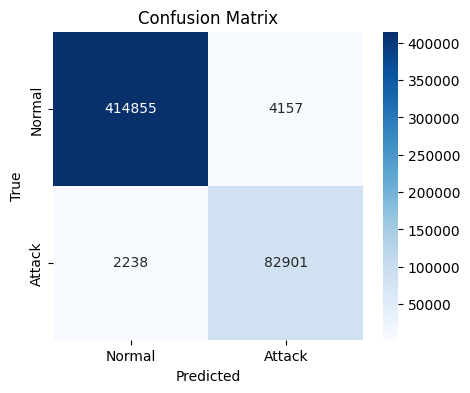

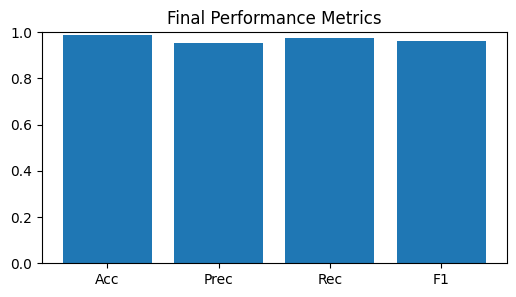

In [14]:
# ===================================
# Cell 6: Final Fine-tune & Evaluation
# ===================================
binary_labels = (y_attack!='Normal Traffic').astype(int)
train_idx,test_idx = train_test_split(np.arange(len(binary_labels)),
                                      test_size=0.2,stratify=binary_labels,random_state=42)
X_train_final,X_test_final = X_sel[train_idx],X_sel[test_idx]
y_train_final,y_test_final = binary_labels[train_idx],binary_labels[test_idx]

ft_model = model_fn_factory().to(device)
ft_model.load_state_dict(meta_model.state_dict())

train_ds = TensorDataset(torch.tensor(X_train_final,dtype=torch.float32),
                         torch.tensor(y_train_final,dtype=torch.long))
test_ds = TensorDataset(torch.tensor(X_test_final,dtype=torch.float32),
                        torch.tensor(y_test_final,dtype=torch.long))
train_loader = DataLoader(train_ds,batch_size=256,shuffle=True)
test_loader  = DataLoader(test_ds,batch_size=512,shuffle=False)

class_counts = np.bincount(y_train_final)
weights = torch.tensor([1/(class_counts[0]+1e-8),1/(class_counts[1]+1e-8)],
                       dtype=torch.float32).to(device)
weights = weights/weights.sum()
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.AdamW(ft_model.parameters(), lr=3e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,'max',factor=0.5,patience=2)

best_f1=0.0
for ep in range(1,11):
    ft_model.train()
    for xb,yb in train_loader:
        xb,yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(ft_model(xb), yb)
        loss.backward(); optimizer.step()
    # eval
    ft_model.eval(); preds=[]; gts=[]
    with torch.no_grad():
        for xb,yb in test_loader:
            xb=xb.to(device)
            out=ft_model(xb)
            p=torch.argmax(out,dim=1).cpu().numpy()
            preds.append(p); gts.append(yb.numpy())
    preds=np.concatenate(preds); gts=np.concatenate(gts)
    f1=f1_score(gts,preds,zero_division=0)
    acc=accuracy_score(gts,preds)
    scheduler.step(f1)
    print(f"Epoch {ep}: acc={acc:.4f}, f1={f1:.4f}")
    if f1>best_f1:
        best_f1=f1
        torch.save(ft_model.state_dict(),"best_ft_model.pth")

ft_model.load_state_dict(torch.load("best_ft_model.pth"))
ft_model.eval(); preds=[]
with torch.no_grad():
    for xb,_ in test_loader:
        xb=xb.to(device)
        preds.append(torch.argmax(ft_model(xb),dim=1).cpu().numpy())
preds=np.concatenate(preds)

acc=accuracy_score(y_test_final,preds)
prec=precision_score(y_test_final,preds,zero_division=0)
rec=recall_score(y_test_final,preds,zero_division=0)
f1=f1_score(y_test_final,preds,zero_division=0)
cm=confusion_matrix(y_test_final,preds)

tn,fp,fn,tp = cm.ravel()
tpr = tp/(tp+fn); tnr = tn/(tn+fp)
fpr = fp/(fp+tn); fnr = fn/(fn+tp)

print("\n===== Final Metrics =====")
print(f"Accuracy : {acc:.2f}")
print(f"Precision: {prec:.2f}")
print(f"Recall   : {rec:.2f}")
print(f"F1 Score : {f1:.2f}")
print("Confusion Matrix:\n",cm)
print(f"TPR={tpr:.4f}, TNR={tnr:.4f}, FPR={fpr:.4f}, FNR={fnr:.4f}")
print("\nClassification Report:\n", classification_report(y_test_final,preds))

# Plot confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
            xticklabels=['Normal','Attack'],yticklabels=['Normal','Attack'])
plt.title("Confusion Matrix"); plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()

# Metrics bar chart
plt.figure(figsize=(6,3))
plt.bar(['Acc','Prec','Rec','F1'],[acc,prec,rec,f1])
plt.ylim(0,1); plt.title("Final Performance Metrics")
plt.show()
